## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Fall 2025

# Homework 3: All the things! (130 points + 20 BONUS)**

- **Due:** November 9 (Sunday), 11:59pm
- **You may use AI assistants**, but you must document your own reasoning and learning process.

***Goals of this homework:***
1. Implement classic, interpretable clustering (K‑Means/DBSCAN).
2. Train and interpret tree‑based models on structured data (Decision Tree, Random Forest).
3. Practice probabilistic deduplication with Bloom filters and evaluate error profiles.
4. Design and communicate your own analysis — pose a question, explore, and visualize insights from the CSCE 676 Interests dataset (Open Exploration).

***Submission instructions:***

You should post your notebook to Canvas (look for the homework 3 assignment there). Please name your submission **your-uin_hw3.ipynb**, so for example, my submission would be something like **555001234_hw3.ipynb**. Your notebook should be fully executed when you submit ... so run all the cells for us so we can see the output, then submit that.

***Late Days:***

As a reminder, you begin the semester with five late days. You may use as many as you like. There is no need to alert us to how many late days you are using. Just submit and we will make note of it. Also remember that once your late days are used up, homeworks will receive a 0.

***Collaboration and AI Assistance declaration:***

If you worked with someone on this homework, please be sure to mention that. Remember to include citations to any sources you use in the homework. Also tell us what AI assistant you used and how you used it.

## (REQUIRED) Collaboration and AI Assistance Declaration

### Collaboration Declaration:

Christian Swords and I discussed embedding usage in part 1

### AI Assistance Declaration:

I used chatgpt in each section to write code quickly and fully explore our data

## Overview

This HW has **three independent, required parts** plus an optional BONUS part.

- **Part 1 (Jeopardy) — Clustering Core.**  
  Step‑by‑step: cleaning → K‑Means/DBSCAN → Analyses

- **Part 2 (Mushroom) — Interpretable Supervised Learning.**  
  Step‑by‑step: Decision Tree (gini vs entropy, depth sweep) → Random Forest → interpretability.

- **Part 3 (Humor) — Probabilistic Filtering & Lightweight Prediction.**  
  Step‑by‑step: derive Bloom parameters → implement Bloom → document your process.

- **BONUS (Interests) — Open Exploration and Creative Analysis.**
  Use the CSCE 676 Interests dataset to ask your own question, apply methods of your choice, and visualize or interpret what you find.

In [2]:
# Data URLs
Jeopardy_data_URL ='https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions'
Mushroom_data_URL ='https://www.kaggle.com/datasets/uciml/mushroom-classification'
Humor_data_URL ='https://www.kaggle.com/datasets/deepcontractor/200k-short-texts-for-humor-detection'

## 0. Environment Setup & Sampling (Optional)

- You may use the full datasets. Sampling is optional (for speed).
- If you sample, briefly report what you did (n/frac, whether you stratified, any seed).
- For Humor stream simulation, you may keep original order or shuffle (your choice—just state it).


In [3]:
###### sampling code (optional)
from pathlib import Path
import pandas as pd

# Edit paths if needed
JEOPARDY_PATH = Path("./JEOPARDY_CSV.csv")
MUSHROOM_PATH = Path("./mushrooms.csv")
HUMOR_PATH    = Path("./humor.csv")   # optional

def load_csv(path, **kwargs):
    if path.exists():
        return pd.read_csv(path, **kwargs)
    print(f"Warning: {path} not found.")
    return None

jeopardy = load_csv(JEOPARDY_PATH)
mushroom = load_csv(MUSHROOM_PATH)
humor    = load_csv(HUMOR_PATH)

# ====== (Optional) Sampling ======
# Leave all values as None to use the full dataset.
SAMPLE = {
    "jeopardy": {"n": None, "frac": None, "random_state": None, "stratify_col": None},  # e.g., {"n": 20000, "random_state": 42}
    "mushroom": {"n": None, "frac": None, "random_state": None, "stratify_col": None},  # e.g., {"frac": 1.0}
    "humor":    {"n": None, "frac": None, "random_state": None, "stratify_col": None},  # e.g., {"frac": 0.7, "random_state": 1}
}

def maybe_sample(df, cfg):
    """Return sampled df if n/frac set; otherwise return df. Optional stratify by a column name."""
    if df is None:
        return None
    n, frac, rs, strat = cfg.get("n"), cfg.get("frac"), cfg.get("random_state"), cfg.get("stratify_col")
    if strat and strat in df.columns and (n or frac):
        # stratified sampling (simple & proportional when using frac)
        if frac:
            return (df.groupby(strat, group_keys=False)
                      .apply(lambda g: g.sample(frac=frac, random_state=rs))
                      .reset_index(drop=True))
        # proportional n by class frequency (rounded)
        counts = df[strat].value_counts(normalize=True) * n
        parts = []
        for k, need in counts.round().astype(int).items():
            part = df[df[strat]==k].sample(n=min(need, len(df[df[strat]==k])), random_state=rs)
            parts.append(part)
        out = pd.concat(parts).reset_index(drop=True)
        return out.sample(frac=1.0, random_state=rs).reset_index(drop=True)
    # simple sampling
    if frac: return df.sample(frac=frac, random_state=rs).reset_index(drop=True)
    if n:    return df.sample(n=min(n, len(df)), random_state=rs).reset_index(drop=True)
    return df.reset_index(drop=True)

jeopardy_sample = maybe_sample(jeopardy, SAMPLE["jeopardy"])
mushroom_sample = maybe_sample(mushroom, SAMPLE["mushroom"])
humor_sample    = maybe_sample(humor,    SAMPLE["humor"]) if (humor is not None) else None

print("Jeopardy:", None if jeopardy is None else jeopardy.shape,
      "-> sample:", None if jeopardy_sample is None else jeopardy_sample.shape)
print("Mushroom:", None if mushroom is None else mushroom.shape,
      "-> sample:", None if mushroom_sample is None else mushroom_sample.shape)
print("Humor:   ", None if humor is None else humor.shape,
      "-> sample:", None if humor_sample is None else humor_sample.shape)


Jeopardy: (216930, 7) -> sample: (216930, 7)
Mushroom: (8124, 23) -> sample: (8124, 23)
Humor:    (200000, 2) -> sample: (200000, 2)


Full datasets

---

## Part 1 — Jeopardy! Questions -> Clustering and Analysis (30pts)

Do you know? _Jeopardy!_ is a popular U.S. quiz show where contestants are given answers and must respond with the questions.
> For example: Answer: “This planet is known as the Red Planet.” Correct question: “What is Mars?”

In this dataset, each question has a Category (topic), Question (text), and Answer (label).
You will analyze patterns in these texts and explore how question wording relates to categories and answers.


### Task1 - Preprocess (10 pts) — Design Choices + Rationale

- Clean the text (e.g., lowercase, remove stopwords/punctuation, optional stemming or lemmatization). You may use any pipeline you like, including optional TF-IDF features, embeddings, or whatever you like. Many packages (e.g., sklearn) come built in with some nice text processing packages.

- Briefly explain your design choices (what steps or parameters you used) and give a short rationale (why you think these choices help).

In [4]:
### 1) Preprocess & TF‑IDF (10 pts)
# Load data
df = pd.read_csv("JEOPARDY_CSV.csv")

# Standardize column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
# print(df.head())

# Drop rows with missing questions
df = df.dropna(subset=["question"]).reset_index(drop=True)

import re
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["clean_question"] = df["question"].apply(clean_text)
df["clean_category"] = df["category"].apply(clean_text)
df["clean_answer"] = df["answer"].apply(clean_text)

print(df.head())


   show_number    air_date      round                         category value  \
0         4680  2004-12-31  Jeopardy!                          HISTORY  $200   
1         4680  2004-12-31  Jeopardy!  ESPN's TOP 10 ALL-TIME ATHLETES  $200   
2         4680  2004-12-31  Jeopardy!      EVERYBODY TALKS ABOUT IT...  $200   
3         4680  2004-12-31  Jeopardy!                 THE COMPANY LINE  $200   
4         4680  2004-12-31  Jeopardy!              EPITAPHS & TRIBUTES  $200   

                                            question      answer  \
0  For the last 8 years of his life, Galileo was ...  Copernicus   
1  No. 2: 1912 Olympian; football star at Carlisl...  Jim Thorpe   
2  The city of Yuma in this state has a record av...     Arizona   
3  In 1963, live on "The Art Linkletter Show", th...  McDonald's   
4  Signer of the Dec. of Indep., framer of the Co...  John Adams   

                                      clean_question  \
0  for the last 8 years of his life galileo was u...  

I have cleaned the question column, removing punctuation and anything that isn't a number or letter (after lowercasing)

TF-IDF

In [5]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df["clean_question"])
print("TF-IDF shape:", X_tfidf.shape)

from sklearn.cluster import KMeans

k = 25
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(X_tfidf)

df["TFIDF_cluster"] = labels

for i in range(k):
    print(f"\nCluster {i}:")
    sample = df[df["TFIDF_cluster"] == i].sample(5, random_state=42)
    print(sample[["clean_category", "clean_question", "clean_answer"]])


TF-IDF shape: (216930, 5000)

Cluster 0:
               clean_category  \
48435   south american beauty   
125101           modern dance   
129666        nuclear physics   
65880       weights  measures   
27080                 pirates   

                                           clean_question      clean_answer  
48435   usual term for the agricultural level seen her...          terraces  
125101  as opposed to the leaps of ballet mary wigmans...          kneeling  
129666  a metal used in making control rods for nuclea...           cadmium  
65880   one unit of this distance used in horse racing...         a furlong  
27080   its the term pirates used for the land along t...  the spanish main  

Cluster 1:
                     clean_category  \
45079                 southern food   
91614                    december 7   
210678             american history   
122651             also a body part   
116653  mr smith goes to washington   

                                           cl

Embeddings (HuggingFace sentence-transformers/all-MiniLM-L6-v2, 384dim)

In [6]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from tqdm import tqdm

model_name = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  # (batch_size, seq_len, hidden_size)
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

def embed_texts(texts, batch_size=64):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Embedding questions", unit="batch"):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, return_tensors='pt', max_length=128).to(device)
            model_out = model(**encoded)
            batch_emb = mean_pooling(model_out, encoded['attention_mask'])
            embeddings.append(batch_emb.cpu())
    return torch.cat(embeddings).numpy()

embeddings = embed_texts(df["clean_question"].tolist())
print("Embeddings shape:", embeddings.shape)


from sklearn.cluster import KMeans

n_clusters = k
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(embeddings)
df["emb_cluster"] = labels

for i in range(n_clusters):
    print(f"\nCluster {i}:")
    sample = df[df["emb_cluster"] == i].sample(5, random_state=42)
    print(sample[["clean_category", "clean_question", "clean_answer"]])

Embedding questions: 100%|██████████| 3390/3390 [01:19<00:00, 42.72batch/s]


Embeddings shape: (216930, 384)

Cluster 0:
            clean_category                                     clean_question  \
53280       movie musicals  vincente minnelli directed judy garland in thi...   
28808   balanchine ballets  concerto barocco is danced to this mans music ...   
176182           hollywood  she won an oscar for her muted performance in ...   
53697       by the numbers  in enrico carusos 1904 contract with victor he...   
95557    broadway musicals  tim hatley won a 2009 tony for best costume de...   

               clean_answer  
53280   meet me in st louis  
28808               js bach  
176182         holly hunter  
53697                   78s  
95557                 shrek  

Cluster 1:
                           clean_category  \
67940                    according to jim   
110034  the continental congress met here   
34942                       organizations   
16733            presidential birthplaces   
161972     exiting george w bushs cabinet   

      

TF-IDF using only occurance data made clusters that were very difficult to humanly understand, our embedded questions now cluster on somewhat similar categories.\
Cluster 0 we see music, dance, and hollywood categories sampled,\
Cluster 3 we see human and science related categories and answers, while\
Cluster 5 we see more science and nature related categories and answers,\
Cluster 14 religion, seeing 2 'david's in the sampled answers,\
Cluster 17 places, ney york, switzerland, and french based questions sampled,\
Cluster 19 food,\
Cluster 24 samples the categories [windmills,castles,museums,romans,cathedrals], a group that I would connotatively say is similar.\
Our embeddings seem to make good clusters with maybe a few filler groups (Cluster 11 seemed to group short niche type questions) and 25 clusters seems about appropriate. we'll attempt visualization and dbscan next.

### Task2 - Clustering with **K‑Means and DBSCAN** (20 pts)

- Run K-Means and `DBSCAN`.
- Report some clustering metrics to assess the quality of clustering (you may consider the Silhouette score for each method, or perhaps `ARI` and `NMI` using the Category labels as ground truth). This part is up to you and designed so you can observe the challenge of evaluating clustering.
- Visualize the clusters (e.g., 2D with `PCA` or `t-SNE`).

Briefly discuss which method performed better and why.


In [7]:
### 2) Clustering: K‑Means & DBSCAN (20 pts)
# K-Means was done above ^^^
from sklearn.metrics import silhouette_score
print("KMeans silhouette:", silhouette_score(embeddings, df["emb_cluster"]))

from sklearn.cluster import DBSCAN

# DBSCAN is sensitive to eps — tune this!
dbscan = DBSCAN(eps=1.5, min_samples=10, metric='euclidean', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

df["dbscan_cluster"] = db_labels

# Inspect how many clusters DBSCAN found
unique, counts = np.unique(db_labels, return_counts=True)
print("DBSCAN clusters (label:count):", dict(zip(unique, counts)))


KMeans silhouette: -0.096439786
DBSCAN clusters (label:count): {-1: 216708, 0: 13, 1: 98, 2: 48, 3: 22, 4: 14, 5: 13, 6: 14}


c:\Users\nick2\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


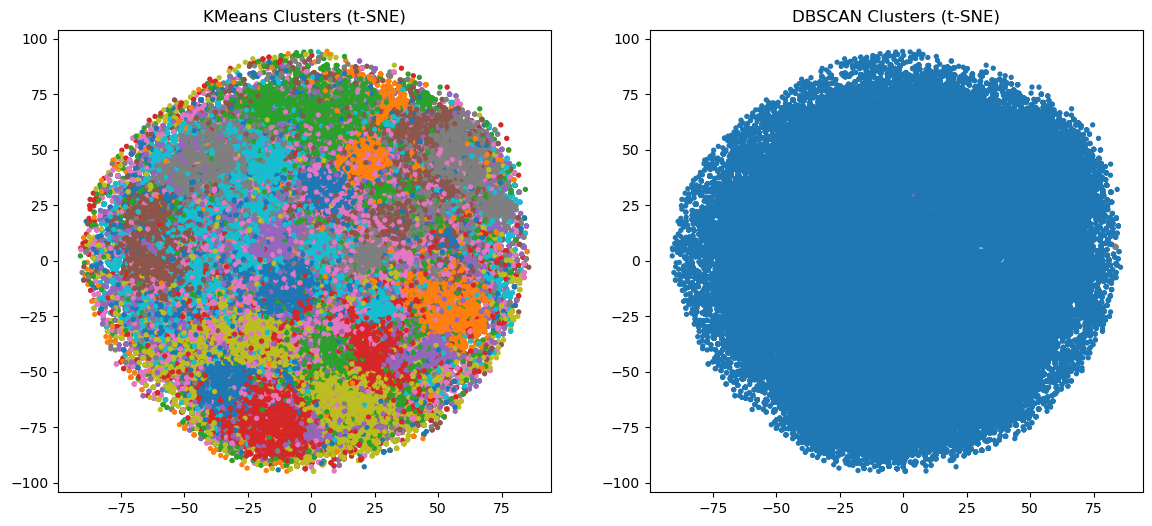

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce to 2D for plotting
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
reduced = tsne.fit_transform(embeddings)

df["tsne_x"] = reduced[:,0]
df["tsne_y"] = reduced[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans
axes[0].scatter(df["tsne_x"], df["tsne_y"], c=df["emb_cluster"], cmap="tab10", s=8)
axes[0].set_title("KMeans Clusters (t-SNE)")

# DBSCAN
axes[1].scatter(df["tsne_x"], df["tsne_y"], c=df["dbscan_cluster"], cmap="tab20", s=8)
axes[1].set_title("DBSCAN Clusters (t-SNE)")

plt.show()


---

## Part 2 — Mushrooms!! -> Decision Trees Classifications (60 pts)

This dataset contains descriptions of mushrooms from the `Agaricus` and `Lepiota` families.

Each sample is labeled as `edible` or `poisonous`, based on observable traits such as `cap shape`, `color`, `odor`, and `habitat`.

All features are categorical, making it a good exercise for preprocessing, encoding, and classification.

> You will `predict` whether a mushroom is edible or poisonous using `classification` methods.

### Taks1 - Decision Tree (20 pts)
- Train a Decision Tree classifier to predict whether each mushroom is edible or poisonous.
- Compare results using both criterion=`gini` and criterion=`entropy`, and sweep over different `max_depth` values.
- Plot test `accuracy` vs. `tree depth` and briefly discuss the effect of overfitting. What do you find out?

In [37]:
### 1) Decision Tree (20 pts)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("mushrooms.csv")

# Columns of interest
cols = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
    "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat"
]
df = df[cols]
le = LabelEncoder()
encoders = {}
for c in df.columns:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    encoders[c] = le

X = df.drop("class", axis=1)
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

depths = range(1, len(cols)-1)
acc_gini, acc_entropy = [], []
for d in depths:
    # Gini
    clf_gini = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    clf_gini.fit(X_train, y_train)
    y_pred_gini = clf_gini.predict(X_test)
    acc_gini.append(accuracy_score(y_test, y_pred_gini))
    
    # Entropy
    clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    clf_entropy.fit(X_train, y_train)
    y_pred_entropy = clf_entropy.predict(X_test)
    acc_entropy.append(accuracy_score(y_test, y_pred_entropy))


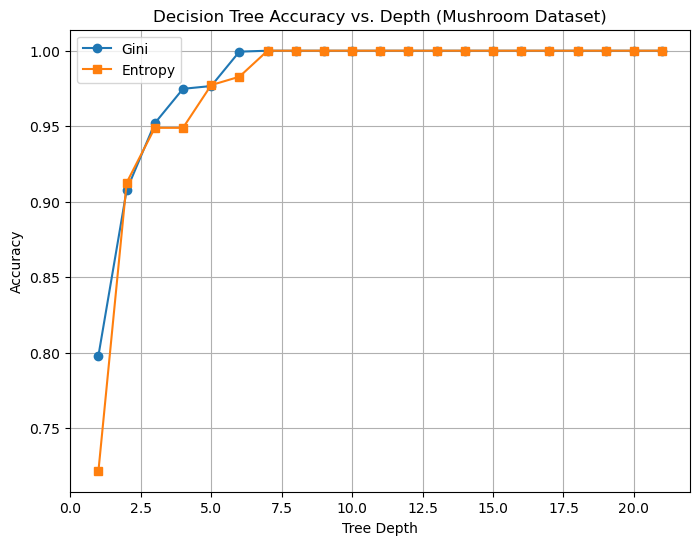

Best Gini accuracy: 1.0000 at depth 7
Best Entropy accuracy: 1.0000 at depth 7


In [38]:
plt.figure(figsize=(8,6))
plt.plot(depths, acc_gini, marker='o', label='Gini')
plt.plot(depths, acc_entropy, marker='s', label='Entropy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. Depth (Mushroom Dataset)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Gini accuracy: {max(acc_gini):.4f} at depth {depths[acc_gini.index(max(acc_gini))]}")
print(f"Best Entropy accuracy: {max(acc_entropy):.4f} at depth {depths[acc_entropy.index(max(acc_entropy))]}")

Gini seems slightly better at separating the classes, but they both are perfect classifiers on the withheld test set at depth 7.

### Task2 - Random Forest (20 pts)

- Train Random Forest classifiers with different numbers of trees — e.g., `n_estimators ∈ {50, 100, 200}`.
- Compare their accuracy to your best single Decision Tree.
- Then, plot the top-10 most important features and discuss which mushroom traits seem most influential.

In [39]:

### 2) Random Forest (20 pts)

from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Estimators to test
n_estimators_list = [50, 100, 200]
rf_results = {}

for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rf_results[n] = {"model": rf, "accuracy": acc}

# Display accuracies
for n, res in rf_results.items():
    print(f"n_estimators={n}: Accuracy={res['accuracy']:.4f}")

best_n = max(rf_results, key=lambda n: rf_results[n]["accuracy"])
best_rf = rf_results[best_n]["model"]

print(f"\nBest Random Forest: {best_n} estimators, accuracy={rf_results[best_n]['accuracy']:.4f}")


n_estimators=50: Accuracy=1.0000
n_estimators=100: Accuracy=1.0000
n_estimators=200: Accuracy=1.0000

Best Random Forest: 50 estimators, accuracy=1.0000


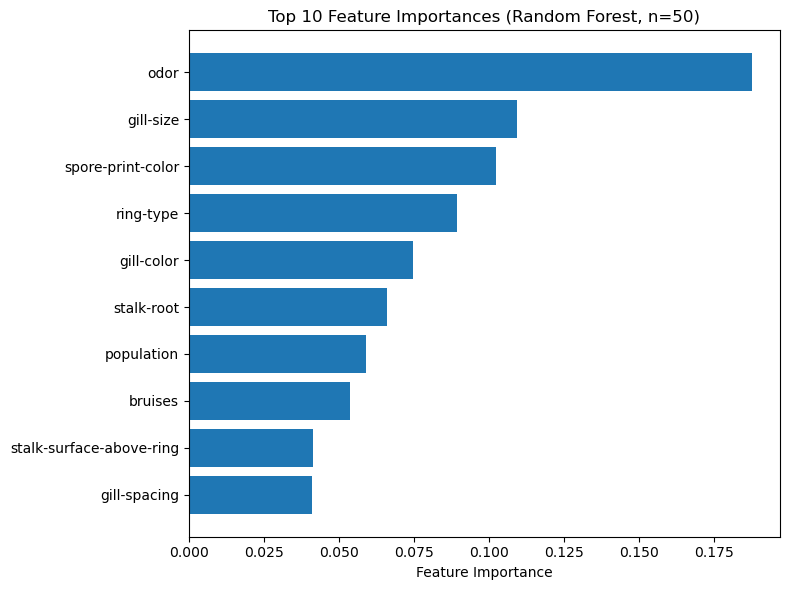

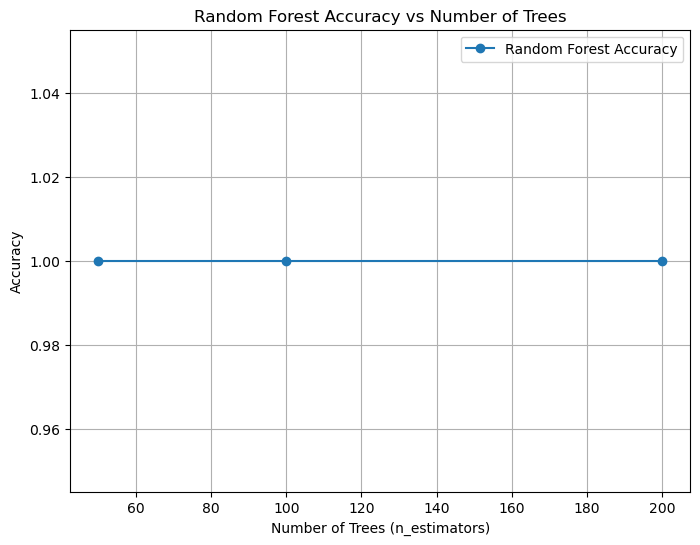

In [40]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]
importance_values = importances[indices]

# Top 10
top_n = 10
top_features = features[:top_n]
top_importances = importance_values[:top_n]

plt.figure(figsize=(8,6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest, n={best_n})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(list(rf_results.keys()), [v["accuracy"] for v in rf_results.values()],
         marker='o', label='Random Forest Accuracy')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.legend()
plt.show()


Our random forests are perfectly accurate at 50 (and even at 5) random trees. This makes sense since our categorical data is well representative of the classes.\
Odor is the most important feature,\
gill size, spore color, and ring size the next most representative,\
gill color, stalk root, population, and bruises next\
As we saw in our first decision tree, in just a few layers we are able to perfectly predict our classes.

### Task3 - Interpretability (20 pts)

- Train a small Decision Tree with max_depth=3 for easy visualization.
- Display the tree structure and manually trace 1–2 samples through the decision path.
- Explain in words why the model makes those predictions.

Test accuracy: 0.9569


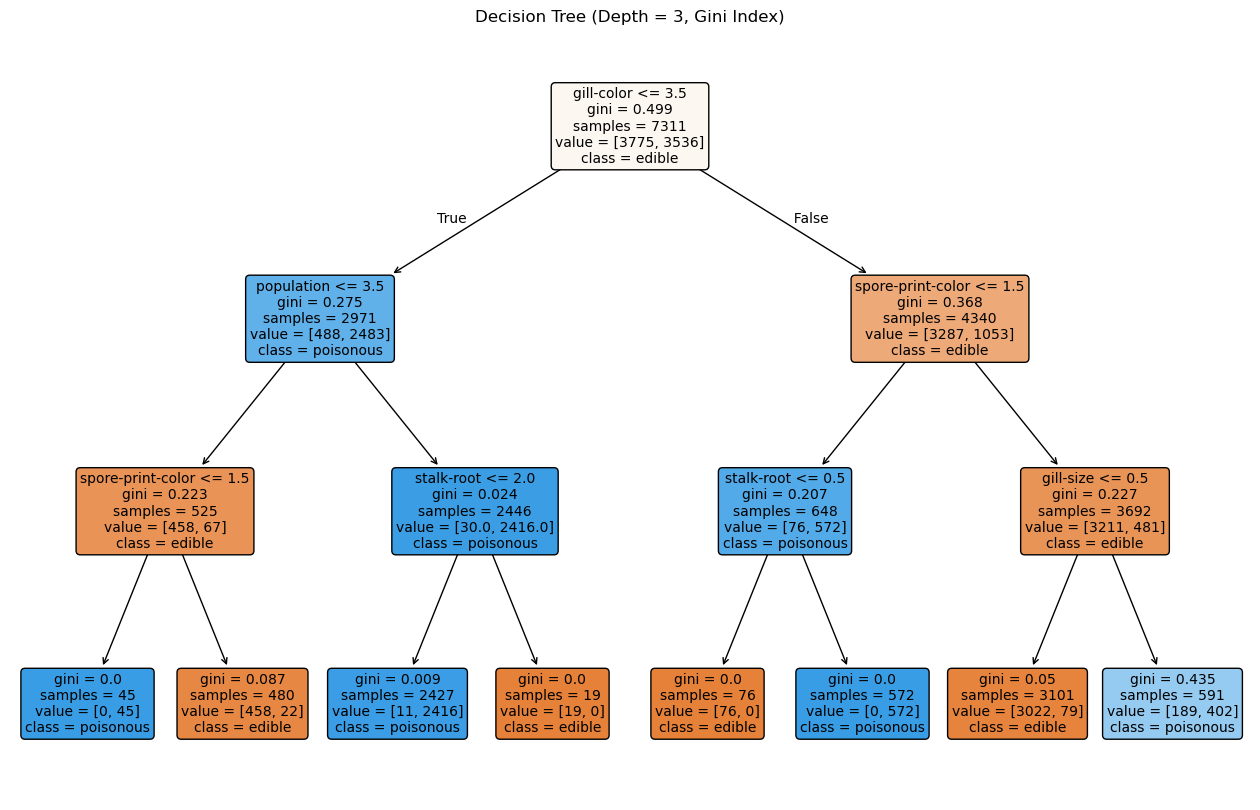


=== Label Encoding Key ===


,feature,0,1,2,3,4,5,6,7,8,9,10,11
0,class,e,p,,,,,,,,,,
1,cap-shape,b,c,f,k,s,x,,,,,,
2,cap-surface,f,g,s,y,,,,,,,,
3,cap-color,b,c,e,g,n,p,r,u,w,y,,
4,bruises,f,t,,,,,,,,,,
5,odor,a,c,f,l,m,n,p,s,y,,,
6,gill-attachment,a,f,,,,,,,,,,
7,gill-spacing,c,w,,,,,,,,,,
8,gill-size,b,n,,,,,,,,,,
9,gill-color,b,e,g,h,k,n,o,p,r,u,w,y


In [50]:

### 3) Interpretability (20 pts)

from sklearn.tree import plot_tree

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=42)
clf = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
clf.fit(X_train, y_train)

print(f"Test accuracy: {clf.score(X_test, y_test):.4f}")

plt.figure(figsize=(16, 10))

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["edible", "poisonous"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Depth = 3, Gini Index)")
plt.show()


# Build a dict: {feature: {code: label}}
encoding_dict = {
    col: {i: label for i, label in enumerate(le.classes_)}
    for col, le in encoders.items()
}

# Convert nested dict to a sparse-like DataFrame
encoding_df = pd.DataFrame.from_dict(encoding_dict, orient="index")

# Reset index to make 'feature' a column
encoding_df.reset_index(inplace=True)
encoding_df.rename(columns={"index": "feature"}, inplace=True)

# Display
print("\n=== Label Encoding Key ===")
display(encoding_df.fillna(""))


# Add a short written explanation under this cell about why splits make sense.


---

## Part 3 — Humor Bloom Filter & Lightweight Baseline (40 pts )
This dataset contains humorous and non-humorous text snippets. Here, we `treat the texts as an incoming data stream`, where new messages keep arriving (like posts, tweets, or comments). You will use a `Bloom Filter`, a space-efficient probabilistic structure for membership testing, to detect whether a message (or phrase) has appeared before and to study how `false positives` grow as the filter fills up.
### Task1 - Bloom Filter (20 pts)

Implement a Bloom Filter for the humor text stream.
- For this part, you should insert the first `70%` of texts as the stream to load your bloom filter.
- As you recall, the two key design parameter are m (the size of the bloom filter) and k (the number of hash functions). Try different choices of m and k and find the theoretical minimum false positive rate (recall the formula we presented in class).
- Now calculate the false positives you get when you check the membership of the remaining 30%. That is, do not insert these 30%, just check IsMember. Here you will measure the `empirical FPR` and compare it with the theoretical expectation. What do you find?



Training items: 140000, Test items: 60000


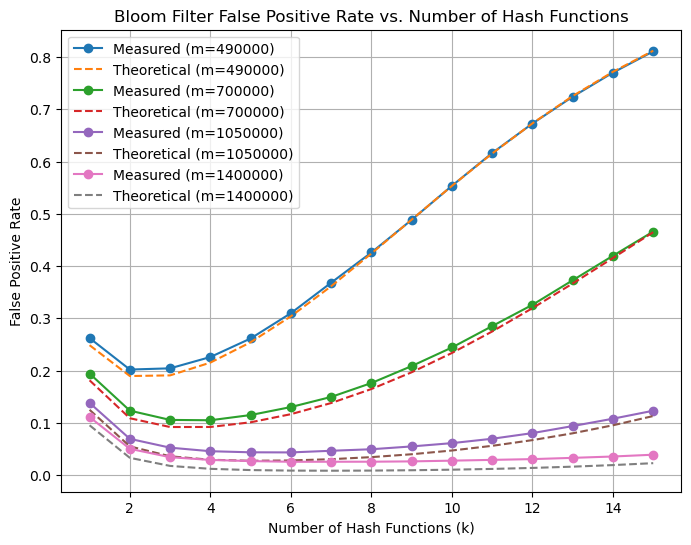

          m  k  measured  theoretical
1    490000  2   0.20190     0.189470
18   700000  4   0.10480     0.091954
35  1050000  6   0.04325     0.027884
50  1400000  6   0.02530     0.008436


In [55]:
# m-bit string B
# n rows
# k hash functions
### 1) Bloom Filter (20 pts)

import re
import mmh3   # fast non-cryptographic hash
import math
import matplotlib.pyplot as plt

# Load dataset (2 columns: text, class)
df = pd.read_csv("humor.csv")

# Ensure proper column names if needed
df.columns = [c.strip().lower() for c in df.columns]
text_col = df.columns[0]
class_col = df.columns[1]

# Basic cleaning
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df[text_col] = df[text_col].apply(clean_text)
split_idx = int(len(df) * 0.7)
train_texts = df[text_col].iloc[:split_idx].tolist()
test_texts  = df[text_col].iloc[split_idx:].tolist()

n = len(train_texts)  # items to insert
print(f"Training items: {n}, Test items: {len(test_texts)}")

class BloomFilter:
    def __init__(self, m, k):
        self.m = m                 # length of bit array
        self.k = k                 # number of hash functions
        self.bit_array = np.zeros(m, dtype=bool)
    
    def _hashes(self, item):
        # Use different seeds for independent hash functions
        return [mmh3.hash(item, seed) % self.m for seed in range(self.k)]
    
    def add(self, item):
        for h in self._hashes(item):
            self.bit_array[h] = True
    
    def check(self, item):
        return all(self.bit_array[h] for h in self._hashes(item))

def measure_fpr(m_values, k_values, train_texts, test_texts):
    results = []
    n = len(train_texts)
    
    for m in m_values:
        for k in k_values:
            bf = BloomFilter(m=m, k=k)
            for t in train_texts:
                bf.add(t)
            
            false_pos = sum(bf.check(t) for t in test_texts)
            fpr = false_pos / len(test_texts)
            
            theoretical = (1 - math.exp(-k * n / m)) ** k
            results.append({"m": m, "k": k, "measured": fpr, "theoretical": theoretical})
    return pd.DataFrame(results)

m_values = [int(3.5*n), 5*n, int(7.5*n), 10*n]   # try several bitstring sizes
k_values = range(1, 16)

fpr_df = measure_fpr(m_values, k_values, train_texts, test_texts)

plt.figure(figsize=(8,6))
for m in m_values:
    subset = fpr_df[fpr_df["m"] == m]
    plt.plot(subset["k"], subset["measured"], marker="o", label=f"Measured (m={m})")
    plt.plot(subset["k"], subset["theoretical"], linestyle="--", label=f"Theoretical (m={m})")

plt.xlabel("Number of Hash Functions (k)")
plt.ylabel("False Positive Rate")
plt.title("Bloom Filter False Positive Rate vs. Number of Hash Functions")
plt.legend()
plt.grid(True)
plt.show()

best = fpr_df.loc[fpr_df.groupby("m")["measured"].idxmin()]
print(best[["m", "k", "measured", "theoretical"]])


We see as we increase the length of our bitstring our FPR lowers and we can use more hash functions. Our graphed m's are [3.5n, 5n, 7.5n, 10n] and we see our optimal k is less than m/n.\
We find each observation very close to our theoretical (1-e^(-km/n))^k.

### Task2 - Most `Efficient' Bloom Filter (20 pts)
- It turns out you can optimize m and k for a given n (the number of elements to store) and p (the false positive probability) to yield a space-efficient Bloom filter. You may need to do a little research to dig into what this optimization is.
- For this part, consider p ∈ {0.5%, 1%, 2%, 5%} and the same 70% of the data as your n. What are the space-efficient m and k for these settings?
- Discuss your findings and how to interpret them.

In [60]:

### 2) Space-efficiency (20 pts)

# Assuming BloomFilter class, df, train_texts, test_texts are already defined
def estimate_m_k(n, p):
    """Estimate optimal m and k for target false positive rate p."""
    m = - (n * math.log(p)) / (math.log(2) ** 2)
    k = (m / n) * math.log(2)
    return int(round(m)), max(1, int(round(k)))  # ensure at least 1 hash function


def measure_empirical_fpr(train_texts, test_texts, m, k):
    bf = BloomFilter(m=m, k=k)
    for t in train_texts:
        bf.add(t)
    false_pos = sum(bf.check(t) for t in test_texts)
    return false_pos / len(test_texts)

target_fprs = [0.005, 0.01, 0.02, 0.05]
results = []

for p in target_fprs:
    m, k = estimate_m_k(n, p)
    measured = measure_empirical_fpr(train_texts, test_texts, m, k)
    results.append({
        "target_FPR": p,
        "m_est": m,
        "k_est": k,
        "measured_FPR": measured
    })

results_df = pd.DataFrame(results)
display(results_df)

,target_FPR,m_est,k_est,measured_FPR
0,0.005,1543885,8,0.022900
1,0.010,1341908,7,0.027300
2,0.020,1139931,6,0.037217
3,0.050,872931,4,0.067300


m=-(n*ln(p))/(ln(2))^2\
k=(m/n)*ln(2)\
As we lower our target FPR, it becomes more difficult to reach with a randomized algorithm, and our theoretical estimates become less accurate.

---

## Part 4 — Open Exploration: CSCE 676 Interests Dataset (Bonus 20 pts)

Background:

This dataset contains the self-reported interests of students in the class. Ideally, we want to find some notion of "community" in our class, but you are welcome to ask any question you like.

Your goal is to ask your own question about this data and explore it creatively using any of the techniques you’ve learned so far. You are welcome to collect any additional info you like (e.g., tags or recent videos from a YouTube channel).

Instructions:

- Formulate one clear research question (e.g., “Do people with similar YouTube interests share similar interests in cartoons?”).

- Choose any appropriate analysis method.

- Show your process and results (figures, tables, or short summaries).

- Briefly interpret your findings — what did you discover or find interesting?




> 👉 Be creative! This part is open-ended — the goal is to demonstrate your ability to ask meaningful questions and analyze real text data.

In [22]:

# Example: visualize frequent keywords or clusters of similar interests

import pandas as pd
import re

# Read with flexible quoting and line handling
df = pd.read_csv("csce676-interests.csv", quotechar='"', skipinitialspace=True, engine="python")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

def normalize_delimiters(text):
    if pd.isna(text):
        return ""
    text = str(text).replace("\n", ",").replace(";", ",").replace("  ", " ")
    # remove spaces after commas
    text = re.sub(r"\s*,\s*", ",", text.strip())
    return text

for col in df.columns:
    if col != "name":
        df[col] = df[col].apply(normalize_delimiters)

for col in df.columns:
    if col != "name":
        df[col] = df[col].apply(lambda x: [s for s in str(x).split(",") if s])

def extract_youtube_id(link):
    # Example: https://www.youtube.com/@SomeChannel or .../channel/... etc.
    match = re.search(r"/@([^/?#]+)", link)
    if match:
        return f"@{match.group(1)}"
    else:
        # fallback: take last section
        parts = [p for p in link.strip("/").split("/") if p]
        return parts[-1] if parts else ""

def extract_meme_id(link):
    # look for /memes/<id>
    match = re.search(r"/memes/([^/?#]+)", link)
    if match:
        return match.group(1)
    parts = [p for p in link.strip("/").split("/") if p]
    return parts[-1] if parts else ""

def extract_cartoon_id(link):
    # look for imdb tt#### code
    match = re.search(r"(tt\d+)", link)
    if match:
        return match.group(1)
    parts = [p for p in link.strip("/").split("/") if p]
    return parts[-1] if parts else ""

df["youtube_ids"] = df["youtube"].apply(lambda lst: [extract_youtube_id(x) for x in lst])
df["meme_ids"]    = df["meme"].apply(lambda lst: [extract_meme_id(x) for x in lst])
df["cartoon_ids"] = df["cartoon"].apply(lambda lst: [extract_cartoon_id(x) for x in lst])

df_clean = df[["name", "youtube_ids", "meme_ids", "cartoon_ids"]]
print(df_clean)


                                name  \
0                     papas-jonathan   
1                               Gerg   
2                     el_psy_congroo   
3                                Yaz   
4                         Student987   
5                      PotatoChicken   
6                         tricksauce   
7                            Leo Das   
8                my_life_is_a_sitcom   
9                          Big Smoke   
10                     aggie-fan-100   
11                    cloud-sky-2000   
12                             Sandy   
13                 mechanical-cactus   
14                    WINTERISCOMING   
15                            crunch   
16                       Ken-Adams-7   
17                  random-name-here   
18                   Dog-Person-1999   
19                      Eugene Krabs   
20                   captain-rs-2023   
21                            legend   
22               hsajz6qie384hf74jrt   
23                         soycheese   


I went through our csv file and cleaned up our data. I standardized our youtube links so the all display youtube.com/@channel_name so we could pull each channel name to look for similarities. I removed meme values that didnt fit our know-your-meme format, and I cleaned our imbd links to fit a /tt#### format we could use on all entries, and removed where users added cartoon_name: [imdb_link]. I corrected most in-line, but I also removed some entries that didn't attempt to follow formatting.

Embedding 85 items from meme_ids...


c:\Users\nick2\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


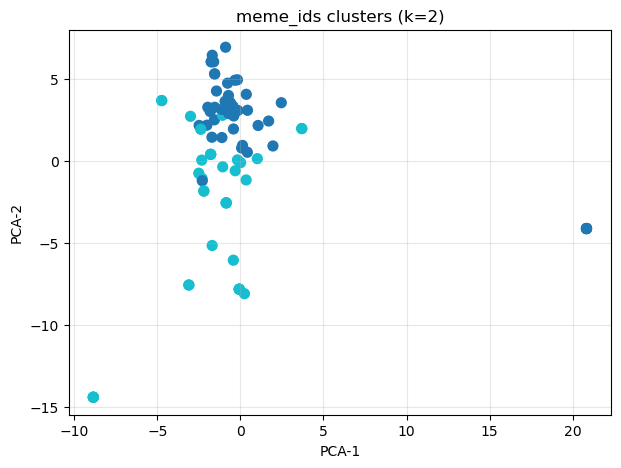

c:\Users\nick2\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster 0 — sample items:
meme_ids
distracted-boyfriend                                  5
but-you-cant-prove-it-james-doakes-reaction-images    2
this-is-fine                                          2
just-a-chill-guy-my-new-character                     2
absolute-cinema                                       1
when-the-imposter-is-sus-sus-jerma                    1
hulk-gives-ant-man-a-taco                             1
why-not-both-why-dont-we-have-both                    1
waffle-falling-over-waffled                           1
i-dont-know-her                                       1

Cluster 1 — sample items:
meme_ids
woman-yelling-at-a-cat               4
doge                                 4
huh-cat                              3
people                               3
6-7-song-67-meme                     2
loss                                 2
forever-alone                        2
sad-hamster-hamster-with-big-eyes    2
pepe-the-frog                        2
cat-looks-inside 

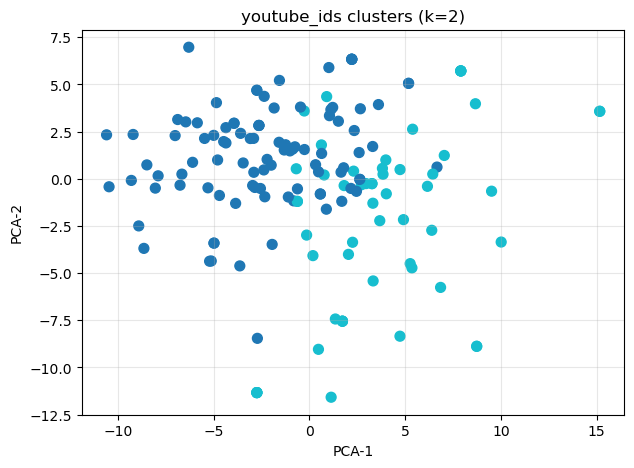

c:\Users\nick2\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster 0 — sample items:
youtube_ids
@mkbhd                 4
@kurzgesagt            3
@CaptainDisillusion    2
@IShowSpeed            2
@3blue1brown           2
@JomboyMedia           2
@dudeperfect           2
@GothamChess           2
@gameranxTV            1
@drdafshow             1

Cluster 1 — sample items:
youtube_ids
@veritasium     4
@PewDiePie      4
@LEMMiNO        3
@SECShorts      2
@ufc            2
@Sidemen        2
@Vsauce         2
@CalebHammer    1
@FilmTheory     1
@fern-tv        1
Embedding 144 items from cartoon_ids...


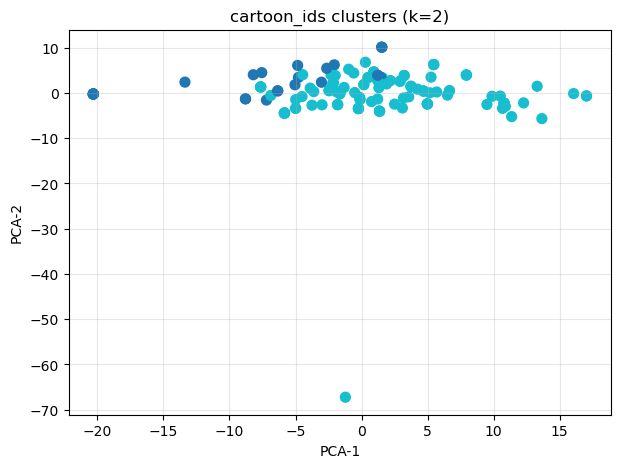


Cluster 0 — sample items:
cartoon_ids
tt2560140     7
tt1361336     3
tt1710308     2
tt12853970    2
tt6517102     2
tt0063950     1
tt1726839     1
tt13706018    1
tt15222080    1
tt1423559     1

Cluster 1 — sample items:
cartoon_ids
tt0206512     7
tt2861424     4
tt0409591     4
tt2098220     4
tt0877057     4
tt0417299     4
tt22248376    3
tt0293734     3
tt4083422     3
tt6741278     3


In [23]:
import pandas as pd
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def get_embeddings(texts, tokenizer, model, device=device):
    all_embeds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), 32):
            batch = texts[i:i+32]
            enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=64).to(device)
            out = model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1).expand(out.last_hidden_state.size()).float()
            emb = torch.sum(out.last_hidden_state * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
            all_embeds.append(emb.cpu().numpy())
    return np.vstack(all_embeds)

def embed_and_cluster(df, col_name, k=5):
    sub = df[["name", col_name]].explode(col_name).dropna(subset=[col_name]).reset_index(drop=True)
    if sub.empty:
        print(f"No data for {col_name}")
        return None

    texts = sub[col_name].astype(str).tolist()
    print(f"Embedding {len(texts)} items from {col_name}...")

    embeddings = get_embeddings(texts, tokenizer, model)

    # Normalize for clustering
    X = StandardScaler().fit_transform(embeddings)

    # Cluster
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    sub["cluster"] = labels

    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    plt.figure(figsize=(7,5))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap="tab10", s=50)
    plt.title(f"{col_name} clusters (k={k})")
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Show top few samples per cluster
    for i in range(k):
        group = sub[sub["cluster"] == i]
        print(f"\nCluster {i} — sample items:")
        print(group[col_name].value_counts().head(10).to_string())

    return sub, embeddings, kmeans

meme_clusters, meme_emb, meme_kmeans = embed_and_cluster(df_clean, "meme_ids", k=2)
youtube_clusters, yt_emb, yt_kmeans = embed_and_cluster(df_clean, "youtube_ids", k=2)
cartoon_clusters, cart_emb, cart_kmeans = embed_and_cluster(df_clean, "cartoon_ids", k=2)


I used the same embedding as before and passed our items in. I displayed each clustering per category and we see some interesting shapes in the data, though hard to discern.

Combined interests per user: (58, 5)
target
0    45
1    13
Name: count, dtype: int64

Decision Tree Accuracy: 0.583
              precision    recall  f1-score   support

           0       0.70      0.78      0.74         9
           1       0.00      0.00      0.00         3

    accuracy                           0.58        12
   macro avg       0.35      0.39      0.37        12
weighted avg       0.53      0.58      0.55        12



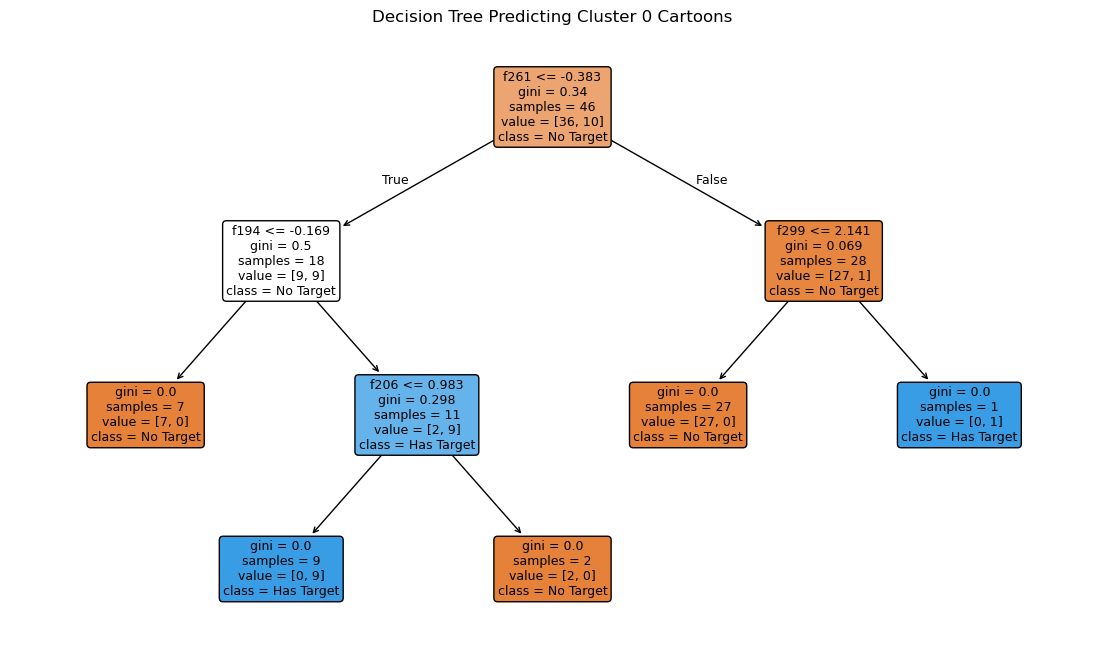

In [24]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"

def get_embeddings(texts, tokenizer, model, device=device):
    model.eval()
    all_embeds = []
    with torch.no_grad():
        for i in range(0, len(texts), 32):
            batch = texts[i:i+32]
            enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=64).to(device)
            out = model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1).expand(out.last_hidden_state.size()).float()
            emb = torch.sum(out.last_hidden_state * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
            all_embeds.append(emb.cpu().numpy())
    return np.vstack(all_embeds)

# combine into one text per user
df_combined = df_clean.copy()
df_combined["all_interests"] = df_combined.apply(
    lambda r: " ".join(r["meme_ids"] + r["youtube_ids"] + r["cartoon_ids"]),
    axis=1
)
print("Combined interests per user:", df_combined.shape)

target_ids = [ # cluster 0
    "tt2560140","tt1361336","tt12853970","tt6517102"]
# target_ids = [ # cluster 1
#     "tt0206512","tt2098220","tt0417299","tt0877057","tt0409591",
#     "tt2861424","tt12343534","tt6741278","tt22248376","tt0220880"
# ]

def has_target(ids):
    return int(any(c in target_ids for c in ids))

df_combined["target"] = df_combined["cartoon_ids"].apply(has_target)
print(df_combined["target"].value_counts())

texts = df_combined["all_interests"].astype(str).tolist()
embeddings = get_embeddings(texts, tokenizer, model)
X = StandardScaler().fit_transform(embeddings)
y = df_combined["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nDecision Tree Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(14,8))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    class_names=["No Target","Has Target"],
    feature_names=[f"f{i}" for i in range(X.shape[1])],
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Predicting Cluster 0 Cartoons")
plt.show()


target
0    31
1    27
Name: count, dtype: int64

Decision Tree Accuracy: 0.500
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12



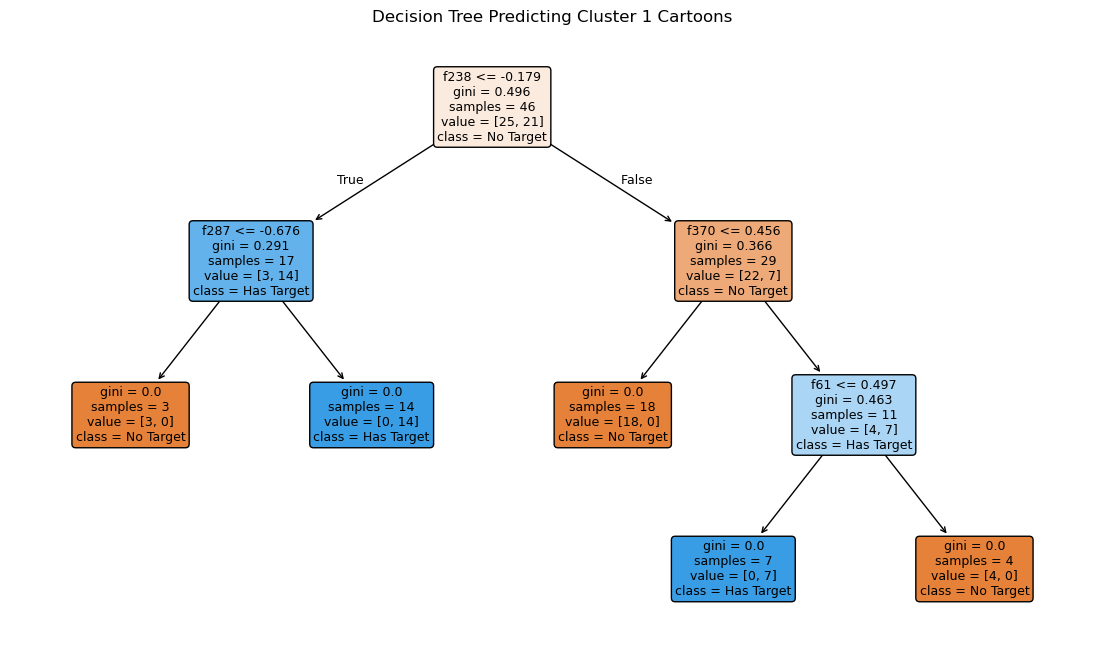

In [25]:
target_ids = [ # cluster 1
    "tt0206512","tt2098220","tt0417299","tt0877057","tt0409591",
    "tt2861424","tt12343534","tt6741278","tt22248376","tt0220880"
]

df_combined["target"] = df_combined["cartoon_ids"].apply(has_target)
print(df_combined["target"].value_counts())

texts = df_combined["all_interests"].astype(str).tolist()
embeddings = get_embeddings(texts, tokenizer, model)
X = StandardScaler().fit_transform(embeddings)
y = df_combined["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nDecision Tree Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(14,8))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    class_names=["No Target","Has Target"],
    feature_names=[f"f{i}" for i in range(X.shape[1])],
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Predicting Cluster 1 Cartoons")
plt.show()


Since our cartoon column had more repeated entries, I used our clustering split and made decision trees to predict if a user's meme and youtube preferences meant they had a target cartoon in either the 0 or 1 cluster.